In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

In [8]:
n = 300

data = pd.DataFrame({
    "age": np.random.randint(18,60,n),
    "salary": np.random.randint(20000,100000,n),
    "balance": np.random.randint(0,200000,n)
})

data["churn"] = (
    (data["balance"] > 100000).astype(int) |
    (data["salary"] < 40000).astype(int)
).astype(int)

data.head()



,age,salary,balance,churn
0,43,73034,181205,1
1,51,34125,123898,1
2,52,97281,123054,1
3,48,67185,108900,1
4,24,75381,86052,0


In [9]:
from pandas.core.api import RangeIndex
print(data.shape)
print(data.info())
print(data.describe())

print(data["churn"].value_counts())


(300, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   age      300 non-null    int64
 1   salary   300 non-null    int64
 2   balance  300 non-null    int64
 3   churn    300 non-null    int64
dtypes: int64(4)
memory usage: 9.5 KB
None
              age        salary        balance       churn
count  300.000000    300.000000     300.000000  300.000000
mean    38.403333  60860.403333   96933.026667    0.623333
std     12.065346  23294.413772   58286.809255    0.485360
min     18.000000  20690.000000     273.000000    0.000000
25%     28.000000  39871.750000   46832.000000    0.000000
50%     39.000000  63040.000000   96159.000000    1.000000
75%     48.250000  80501.000000  147365.750000    1.000000
max     59.000000  99805.000000  198192.000000    1.000000
churn
1    187
0    113
Name: count, dtype: int64


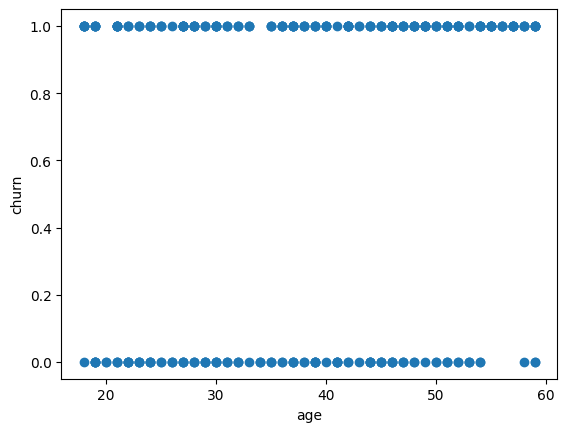

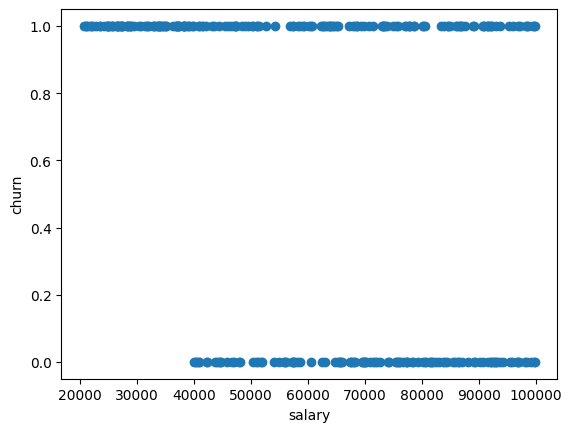

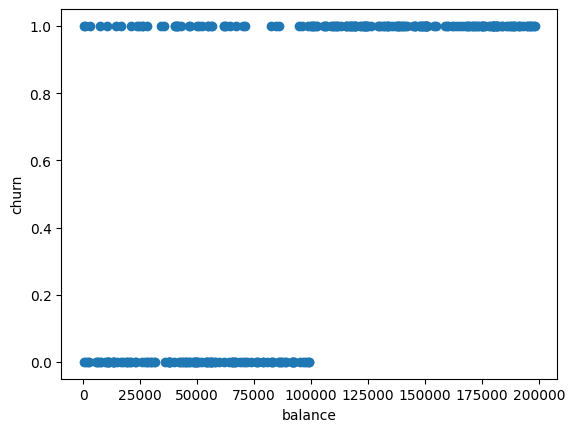

In [10]:
features = ["age","salary","balance"]

for col in features:
  plt.figure()
  plt.scatter(data[col],data["churn"])
  plt.xlabel(col)
  plt.ylabel("churn")
  plt.show()


In [19]:
X = data [["age","salary","balance"]]
y = data["churn"]

In [20]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y, test_size=0.2, random_state=42
)

In [22]:
model = LogisticRegression(max_iter = 1000)
model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [23]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]


In [24]:
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("Classification Report:\n",classification_report(y_test,y_pred))
print("ROC AUC Score:",roc_auc_score(y_test,y_prob))

Accuracy: 0.9166666666666666
Confusion Matrix:
 [[27  2]
 [ 3 28]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.93      0.92        29
           1       0.93      0.90      0.92        31

    accuracy                           0.92        60
   macro avg       0.92      0.92      0.92        60
weighted avg       0.92      0.92      0.92        60

ROC AUC Score: 0.9632925472747498


In [25]:
coeff_df = pd.DataFrame({
    "features": X_train.columns,
    "coefficients": model.coef_[0]
})

print(coeff_df)

  features  coefficients
0      age      0.071705
1   salary     -0.000126
2  balance      0.000076


In [26]:
new_data = pd.DataFrame({
    "age":[35],
    "salary":[30000],
    "balance":[150000]
})

print("churn Prediction:",model.predict(new_data)[0])
print("churn Probability:",model.predict_proba(new_data)[0][1])


churn Prediction: 1
churn Probability: 0.9999336936519458
